<a href="https://colab.research.google.com/github/Janmeshree/ML-PRACS/blob/main/ML_KERAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
!pip install tensorflow

In [16]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [17]:
iris = load_iris()

X = iris.data
y = iris.target

In [18]:
np.random.seed(42)
noise = np.random.normal(0, 0.1, X.shape)
X = X + noise

In [19]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

y = keras.utils.to_categorical(y)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [21]:
model = keras.Sequential([
    layers.Dense(8, activation='relu', input_shape=(4,)),
    layers.Dense(6, activation='relu'),
    layers.Dense(3, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [23]:
history = model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=8,
    validation_split=0.2,
    verbose=0
)

In [24]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", round(accuracy * 100, 2), "%")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9474 - loss: 0.1655
Test Accuracy: 94.74 %


In [25]:
pred = model.predict(X_test)

print("Predicted:", np.argmax(pred, axis=1))
print("Actual:   ", np.argmax(y_test, axis=1))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Predicted: [1 0 2 2 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 2
 0]
Actual:    [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0]


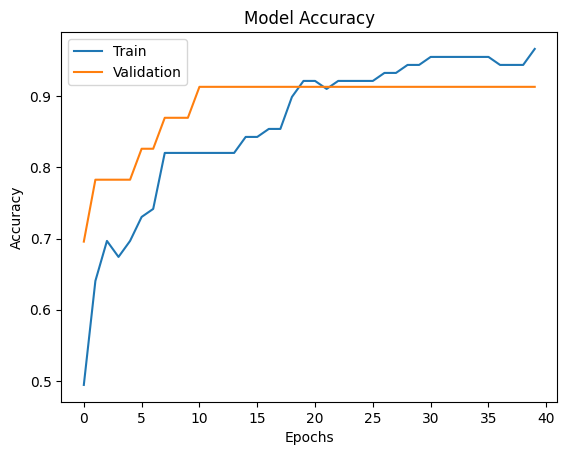

In [26]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')

plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()